# Download and mask ERA5 data for Morocco

This notebook downloads monthly ERA5 temperature data from the Copernicus Climate Data Store using `cdsapi`, extracts the NetCDF file, applies a precise Morocco mask using Natural Earth boundaries, previews the result, and saves the final masked NetCDF.

Before running it, make sure your CDS credentials are configured in `~/.cdsapirc`.


In [31]:
from importlib import reload
from pathlib import Path

import cdsapi
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import geopandas as gpd
import regionmask
from shapely.ops import unary_union

import c3s_atlas.customized_regions as cr
from c3s_atlas.utils import extract_zip_and_delete


## Resolve project paths

This makes the notebook work whether Jupyter was started from the repository root or from a subdirectory.

In [32]:
repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "c3s_atlas").exists() and (path / "auxiliar").exists()
)

dest = repo_root / "book" / "customizing" / "data" / "morocco_era5"
dest.mkdir(parents=True, exist_ok=True)

repo_root, dest


(PosixPath('/home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main'),
 PosixPath('/home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/morocco_era5'))

## Download ERA5 from CDS

The request uses the `multi-origin-c3s-atlas` dataset already used in this repository. The geographical subset is a broad Morocco bounding box, and the precise continent mask is applied afterward.

In [33]:
c = cdsapi.Client()

zip_path = dest / "t_ERA5_Morocco.zip"
dataset = "multi-origin-c3s-atlas"
request = {
    "origin": "era5",
    "domain": "global",
    "period": "1940-2024",
    "variable": "monthly_temperature",
    "bias_adjustment": "no_bias_adjustment",
    "area": [37, -18, 20, 0],
}

if not list(dest.glob("*.nc")):
    c.retrieve(dataset, request).download(zip_path)
    extract_zip_and_delete(zip_path)
    print("Download and extraction complete.")
else:
    print(f"NetCDF already present in {dest}")


NetCDF already present in /home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/morocco_era5


## Open the downloaded NetCDF

In [34]:
nc_files = sorted(
    path for path in dest.glob("*.nc")
    if path.name != "era5_morocco_masked.nc"
)
if not nc_files:
    raise FileNotFoundError(f"No NetCDF file found in {dest}")

nc_path = nc_files[0]
ds = xr.open_dataset(nc_path)

print("Opened:", nc_path.name)
print("Dimensions:", ds.dims)
print("Data variables:", list(ds.data_vars))
ds


Opened: t_ERA5_Morocco.nc
Dimensions: FrozenMappingWarningOnValuesAccess({'lat': 69, 'bnds': 2, 'lon': 73, 'time': 1020})
Data variables: ['lat_bnds', 'lon_bnds', 'time_bnds', 't', 'crs']


<xarray.Dataset> Size: 21MB
Dimensions:    (lat: 69, bnds: 2, lon: 73, time: 1020)
Coordinates:
  * lat        (lat) float64 552B 20.0 20.25 20.5 20.75 ... 36.5 36.75 37.0
  * lon        (lon) float64 584B -18.0 -17.75 -17.5 -17.25 ... -0.5 -0.25 0.0
  * time       (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
    height2m   float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (lat, bnds) float64 1kB ...
    lon_bnds   (lon, bnds) float64 1kB ...
    time_bnds  (time, bnds) datetime64[ns] 16kB ...
    t          (time, lat, lon) float32 21MB ...
    crs        int32 4B ...
Attributes: (12/26)
    Conventions:                CF-1.9 ACDD-1.3
    title:                      Copernicus Interactive Climate Atlas: gridded...
    summary:                    Monthly/annual gridded data from observations...
    institution:                Copernicus Climate Change Service (C3S)
    producers:                  Institute of Physics of Cantabria (IFCA, CSIC...
    license:                    CC-BY 4.0, https://creativecommons.org/licens...
    ...                         ...
    geospatial_lon_max:         179.875
    geospatial_lon_resolution:  0.25
    geospatial_lon_units:       degrees_east
    date_created:               2025-03-26 16:45:54.743007+01:00
    tracking_id:                b868b9c8-72fb-42b6-a397-eee5cd0c62f1
    project_id:                 c3s-cica-atlas

## Build a precise Morocco mask from Natural Earth and apply it

This uses the Natural Earth country boundaries directly and keeps only Morocco in the final NetCDF.


In [35]:
reload(cr)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip"
)

# Natural Earth usually separates Morocco and Western Sahara, so we dissolve both
# into one mask to keep the full Morocco-focused area expected in this project.
mask_names = {"Morocco", "Western Sahara", "W. Sahara"}
morocco_gdf = world[
    world["NAME"].isin(mask_names)
    | world["ADMIN"].isin(mask_names)
    | world["SOVEREIGNT"].isin(mask_names)
].copy()
if morocco_gdf.empty:
    raise ValueError("Morocco / Western Sahara polygons not found in Natural Earth layer")

# Fix possible geometry issues before dissolving into one country polygon.
morocco_gdf["geometry"] = morocco_gdf.geometry.buffer(0)
morocco_shape = unary_union(morocco_gdf.geometry)

# Slightly enlarge the mask so border cells touching Morocco are kept instead of
# being dropped when only the grid-cell centre falls just outside the boundary.
mask_buffer_deg = 0.20
morocco_mask_shape = morocco_shape.buffer(mask_buffer_deg)

morocco_region = regionmask.Regions(
    [morocco_mask_shape],
    names=["Morocco"],
    abbrevs=["MAR"],
    name="Morocco country with Western Sahara",
)

mask = morocco_region.mask(ds["lon"], ds["lat"])
ds_morocco = ds.where(mask == 0)
ds_morocco = cr.crop_to_bbox(ds_morocco, lon_bounds=(-17.5, -0.5), lat_bounds=(20.0, 36.5))

print("Moroccan features used:", len(morocco_gdf))
print("Sample names:", morocco_gdf["NAME"].tolist())
print("Mask buffer (degrees):", mask_buffer_deg)
print("Masked dimensions:", ds_morocco.dims)
print("Masked variables:", list(ds_morocco.data_vars))
ds_morocco


Moroccan features used: 2
Sample names: ['Morocco', 'W. Sahara']
Mask buffer (degrees): 0.2
Masked dimensions: FrozenMappingWarningOnValuesAccess({'lat': 67, 'bnds': 2, 'lon': 69, 'time': 1020})
Masked variables: ['lat_bnds', 'lon_bnds', 'time_bnds', 't', 'crs']


<xarray.Dataset> Size: 95MB
Dimensions:    (lat: 67, bnds: 2, lon: 69, time: 1020)
Coordinates:
  * lat        (lat) float64 536B 20.0 20.25 20.5 20.75 ... 36.0 36.25 36.5
  * lon        (lon) float64 552B -17.5 -17.25 -17.0 -16.75 ... -1.0 -0.75 -0.5
  * time       (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2024-12-01
    height2m   float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (lat, bnds, lon) float64 74kB nan nan nan nan ... nan nan nan nan
    lon_bnds   (lon, bnds, lat) float64 74kB nan nan nan nan ... nan nan nan nan
    time_bnds  (time, bnds, lat, lon) datetime64[ns] 75MB NaT NaT ... NaT NaT
    t          (time, lat, lon) float32 19MB nan nan nan nan ... nan nan nan nan
    crs        (lat, lon) float64 37kB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/26)
    Conventions:                CF-1.9 ACDD-1.3
    title:                      Copernicus Interactive Climate Atlas: gridded...
    summary:                    Monthly/annual gridded data from observations...
    institution:                Copernicus Climate Change Service (C3S)
    producers:                  Institute of Physics of Cantabria (IFCA, CSIC...
    license:                    CC-BY 4.0, https://creativecommons.org/licens...
    ...                         ...
    geospatial_lon_max:         179.875
    geospatial_lon_resolution:  0.25
    geospatial_lon_units:       degrees_east
    date_created:               2025-03-26 16:45:54.743007+01:00
    tracking_id:                b868b9c8-72fb-42b6-a397-eee5cd0c62f1
    project_id:                 c3s-cica-atlas

## Quick preview

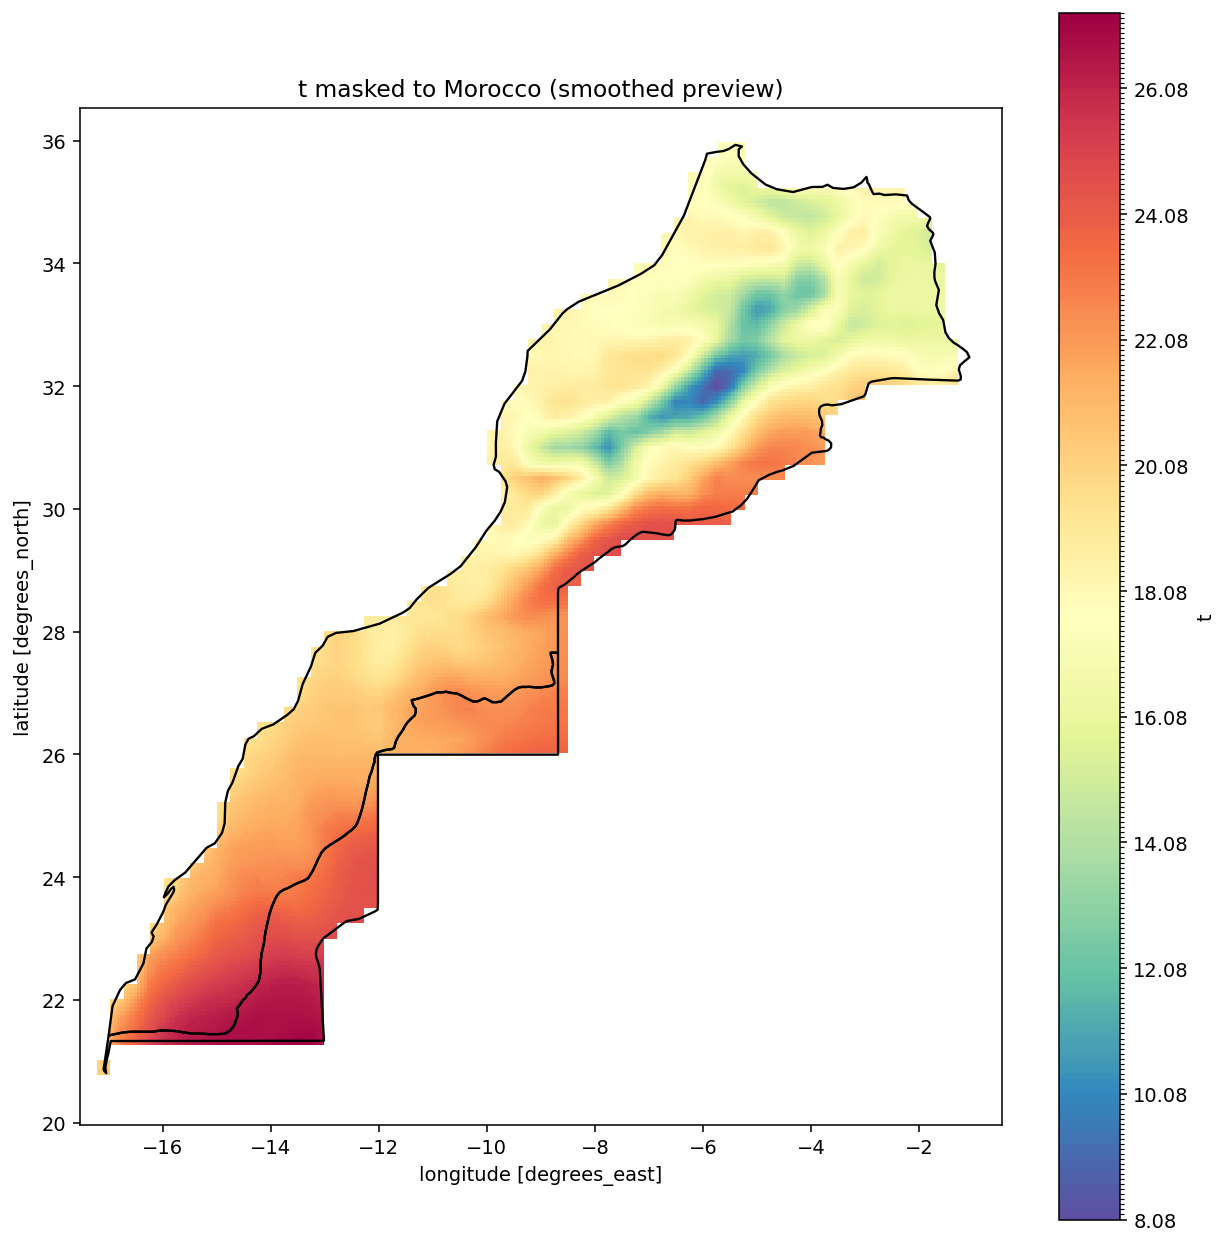

In [36]:
preferred_vars = ["t", "t2m", "tas", "monthly_temperature"]
var_name = next((name for name in preferred_vars if name in ds_morocco.data_vars), None)

if var_name is None:
    candidates = [
        name for name, da in ds_morocco.data_vars.items()
        if {"lat", "lon"}.issubset(da.dims) and "bnds" not in da.dims
    ]
    if not candidates:
        raise ValueError("No plottable data variable with lat/lon dimensions was found.")
    var_name = candidates[0]

da = ds_morocco[var_name]
time_dims = [dim for dim in ("time", "valid_time") if dim in da.dims]
plot_da = da.mean(time_dims[0], skipna=True) if time_dims else da

# Visual-only smoothing: preserve the original NetCDF values, but interpolate to a finer
# preview grid so the notebook map looks less pixelated over Morocco.
plot_da_hi = plot_da.interp(
    lon=np.linspace(float(plot_da.lon.min()), float(plot_da.lon.max()), plot_da.sizes["lon"] * 4),
    lat=np.linspace(float(plot_da.lat.min()), float(plot_da.lat.max()), plot_da.sizes["lat"] * 4),
    method="linear",
)

fig, ax = plt.subplots(figsize=(9, 9), dpi=140)
plot_da_hi.plot(ax=ax, cmap="Spectral_r", levels=255)
morocco_gdf.boundary.plot(ax=ax, color="black", linewidth=1.2)
ax.set_title(f"{var_name} masked to Morocco (smoothed preview)")
plt.tight_layout()
plt.show()


## Save the final Morocco-only NetCDF

This drops auxiliary bounds variables before writing to keep the output cleaner and lighter.


In [37]:
bounds_vars = [name for name in ds_morocco.variables if "bnds" in name.lower() or name.lower().endswith("_bounds")]
ds_morocco_clean = ds_morocco.drop_vars(bounds_vars, errors="ignore")
ds_morocco_clean.attrs.pop("source", None)
output_path = dest / "era5_morocco_masked.nc"

if output_path.exists():
    output_path.unlink()

ds.close()

encoding = {
    name: {"zlib": True, "complevel": 1}
    for name in ds_morocco_clean.data_vars
}

ds_morocco_clean.to_netcdf(output_path, encoding=encoding)
print("Saved:", output_path)


Saved: /home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/data/morocco_era5/era5_morocco_masked.nc
